# Telecom KPI EDA

This notebook performs exploratory data analysis on `data/processed/network_kpi.csv`.

Main goals:
- understand the structure of the dataset
- compare normal vs incident KPI behavior
- visualize one source file over time
- inspect rolling patterns that may help modeling

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [5]:
# Load the processed dataset.
data_path = Path("../data/processed/network_kpi.csv")
df = pd.read_csv(data_path)

print("Dataset loaded from:", data_path)
df.head()

Dataset loaded from: ../data/processed/network_kpi.csv


,timestamp,kpi_value,source_file,issue_status
0,0,504.358938,r1,0
1,300,482.260963,r1,0
2,600,460.701918,r1,0
3,900,463.991321,r1,0
4,1200,439.626319,r1,0


## 1. Dataset structure

The first step is to confirm shape, columns, data types, and basic structure before plotting anything.

In [17]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nBasic info:")
df.info()

Shape: (150332, 4)

Columns:
['timestamp', 'kpi_value', 'source_file', 'issue_status']

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150332 entries, 0 to 150331
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   timestamp     150332 non-null  int64  
 1   kpi_value     150332 non-null  float64
 2   source_file   150332 non-null  object 
 3   issue_status  150332 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 4.6+ MB


Insight:
- `timestamp` gives the time order inside each source file.
- `kpi_value` is the main signal we want to monitor.
- `source_file` identifies which KPI series a row belongs to.
- `issue_status` is the target label: `1` means incident, `0` means normal.

## 2. Missing values and class balance

Before training or deeper analysis, check data quality and the balance between normal and incident rows.

In [18]:
print("Missing values by column:")
print(df.isna().sum())

print("\nissue_status value counts:")
print(df["issue_status"].value_counts())

Missing values by column:
timestamp       0
kpi_value       0
source_file     0
issue_status    0
dtype: int64

issue_status value counts:
issue_status
0    139587
1     10745
Name: count, dtype: int64


Insight:
- If missing values are low or zero, preprocessing becomes easier.
- If `issue_status = 1` is much smaller than `0`, the dataset is imbalanced and recall becomes important.

## 3. Distribution of KPI values

This helps show the overall spread of the KPI signal.

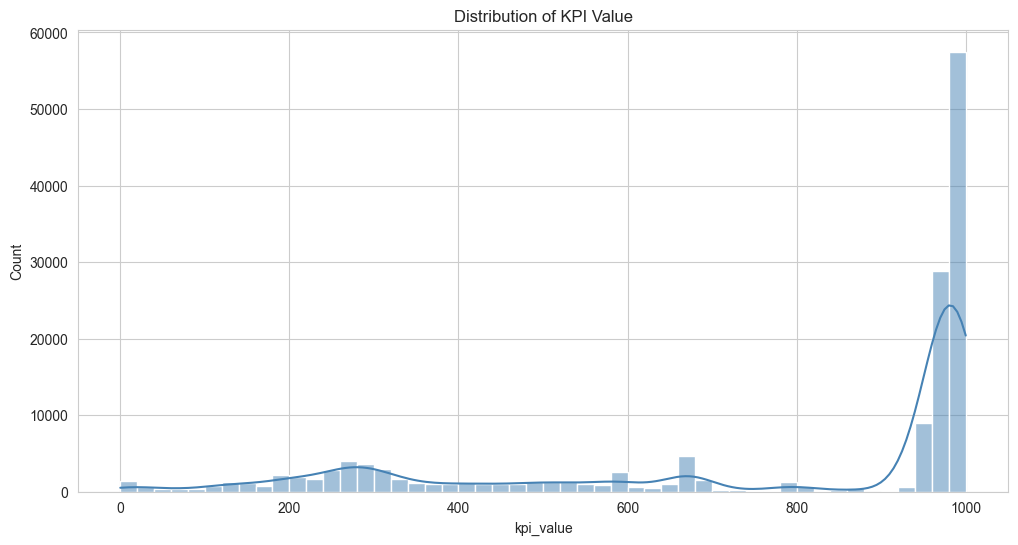

In [19]:
plt.figure()
sns.histplot(df["kpi_value"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of KPI Value")
plt.xlabel("kpi_value")
plt.ylabel("Count")
plt.show()

Insight:
- A wide spread may indicate changing operating conditions.
- Very sharp drops or unusual ranges may be linked to incident periods.

## 4. Time series view for one source file

Use `r1` as a simple example. Incident regions are highlighted in red.

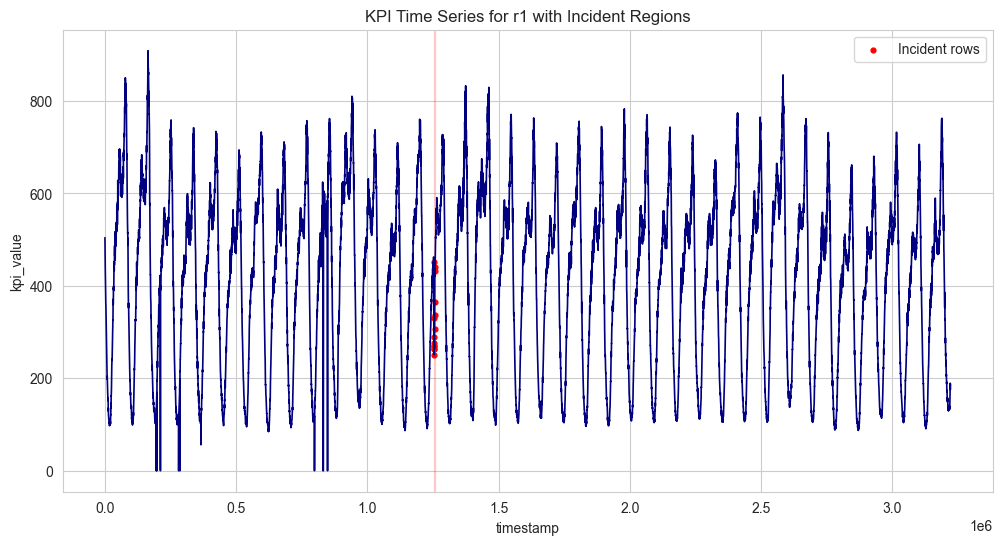

In [20]:
source_name = "r1"
source_df = df[df["source_file"] == source_name].copy()
source_df = source_df.sort_values("timestamp").reset_index(drop=True)

plt.figure()
plt.plot(source_df["timestamp"], source_df["kpi_value"], color="navy", linewidth=1.2)

# Highlight incident rows directly on the time series.
incident_rows = source_df[source_df["issue_status"] == 1]
if not incident_rows.empty:
    plt.scatter(
        incident_rows["timestamp"],
        incident_rows["kpi_value"],
        color="red",
        s=12,
        label="Incident rows"
    )

    incident_blocks = (incident_rows.index.to_series().diff().fillna(1) != 1).cumsum()
    for _, block in incident_rows.groupby(incident_blocks):
        start_time = block["timestamp"].iloc[0]
        end_time = block["timestamp"].iloc[-1]
        plt.axvspan(start_time, end_time, color="red", alpha=0.15)

plt.title(f"KPI Time Series for {source_name} with Incident Regions")
plt.xlabel("timestamp")
plt.ylabel("kpi_value")
plt.legend()
plt.show()

Insight:
- Highlighted regions make it easier to see whether incidents happen after drops, spikes, or unstable behavior.
- This visual check is useful before choosing model features.

## 5. Compare normal vs incident KPI values

This compares the KPI distribution for `issue_status = 0` and `issue_status = 1`.

/var/folders/8t/nh505m9x7j5crx6rdlz4b4x00000gn/T/ipykernel_8621/923184489.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="issue_status", y="kpi_value", palette="Set2")


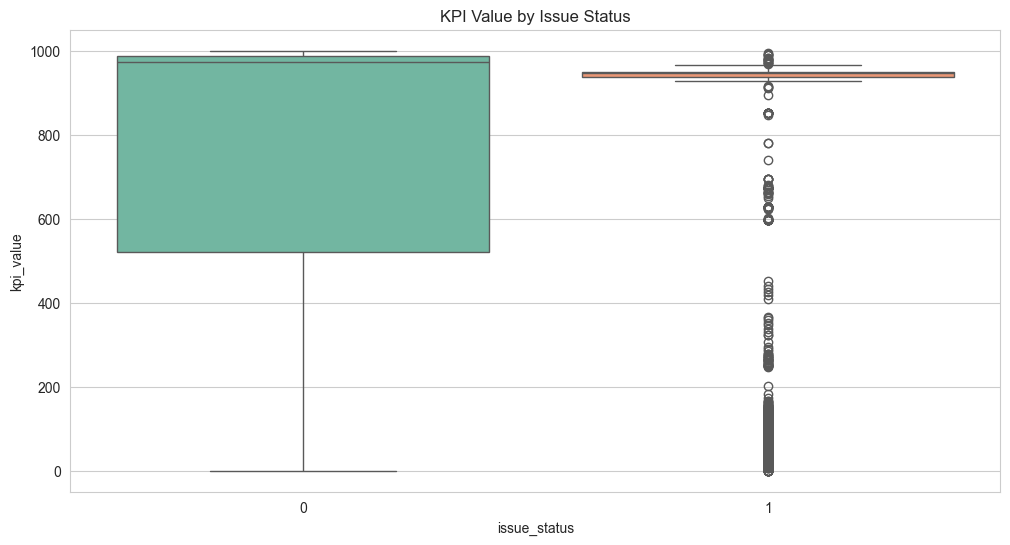

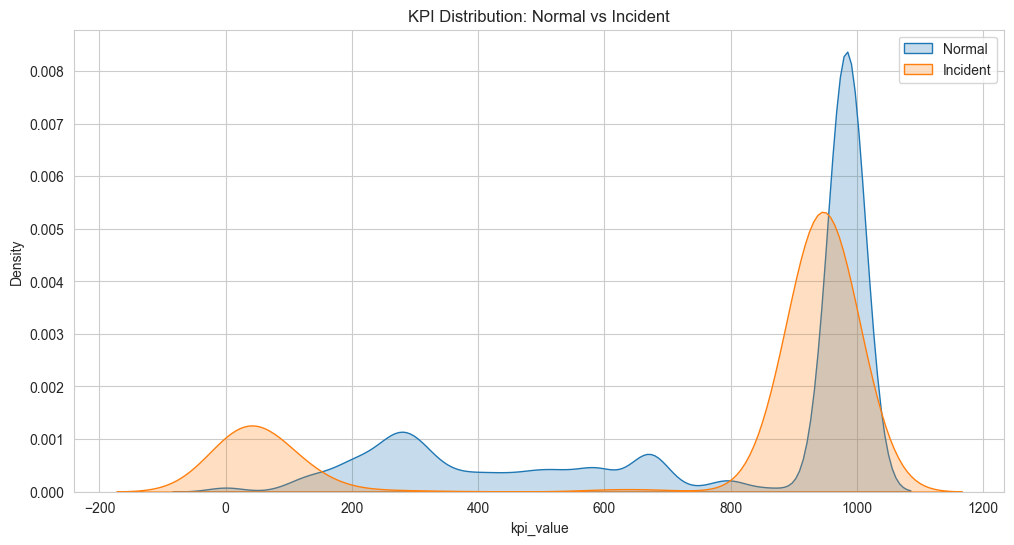

In [21]:
plt.figure()
sns.boxplot(data=df, x="issue_status", y="kpi_value", palette="Set2")
plt.title("KPI Value by Issue Status")
plt.xlabel("issue_status")
plt.ylabel("kpi_value")
plt.show()

plt.figure()
sns.kdeplot(data=df[df["issue_status"] == 0], x="kpi_value", label="Normal", fill=True)
sns.kdeplot(data=df[df["issue_status"] == 1], x="kpi_value", label="Incident", fill=True)
plt.title("KPI Distribution: Normal vs Incident")
plt.xlabel("kpi_value")
plt.ylabel("Density")
plt.legend()
plt.show()

Insight:
- If incident and normal distributions overlap heavily, one feature alone may not be enough.
- That is a good reason to add rolling features and change-based features.

## 6. Rolling mean and rolling standard deviation

These features help visualize local trend and local variability for a source file.

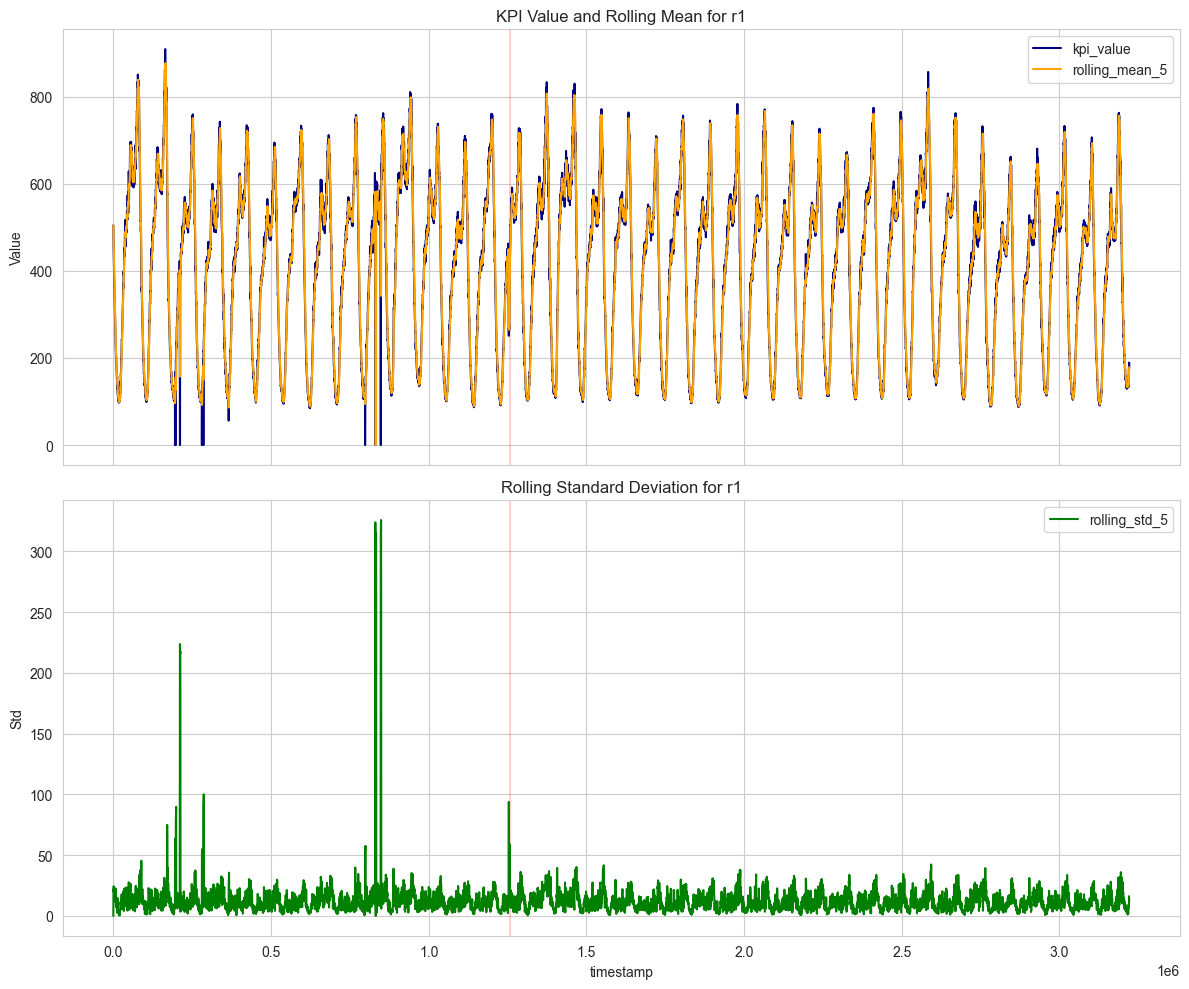

In [22]:
source_df["rolling_mean_5"] = source_df["kpi_value"].rolling(window=5, min_periods=1).mean()
source_df["rolling_std_5"] = source_df["kpi_value"].rolling(window=5, min_periods=1).std().fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

axes[0].plot(source_df["timestamp"], source_df["kpi_value"], label="kpi_value", color="navy")
axes[0].plot(source_df["timestamp"], source_df["rolling_mean_5"], label="rolling_mean_5", color="orange")
axes[0].set_title(f"KPI Value and Rolling Mean for {source_name}")
axes[0].set_ylabel("Value")
axes[0].legend()

axes[1].plot(source_df["timestamp"], source_df["rolling_std_5"], label="rolling_std_5", color="green")
axes[1].set_title(f"Rolling Standard Deviation for {source_name}")
axes[1].set_xlabel("timestamp")
axes[1].set_ylabel("Std")
axes[1].legend()

for ax in axes:
    incident_rows = source_df[source_df["issue_status"] == 1]
    if not incident_rows.empty:
        incident_blocks = (incident_rows.index.to_series().diff().fillna(1) != 1).cumsum()
        for _, block in incident_rows.groupby(incident_blocks):
            start_time = block["timestamp"].iloc[0]
            end_time = block["timestamp"].iloc[-1]
            ax.axvspan(start_time, end_time, color="red", alpha=0.12)

plt.tight_layout()
plt.show()

Insight:
- Rolling mean shows local trend more clearly than raw values alone.
- Rolling standard deviation shows short-term instability, which can be useful for detecting abnormal network behavior.
- If incident regions align with volatility or trend shifts, these features are good candidates for modeling.

## 7. Cell3 internet traffic EDA
This section focuses on the busiest `CellID` in the Cell3 dataset, defined as the cell with the highest mean internet traffic across the full seven-day period.

In [ ]:
cell3_files = sorted(Path("../data/Cell3_Data").glob("sms-call-internet-mi-2013-11-*.csv"))
cell3_df = pd.concat((pd.read_csv(path, usecols=["CellID", "datetime", "internet"]) for path in cell3_files), ignore_index=True)
cell3_df = cell3_df.dropna(subset=["internet"]).copy()
cell3_df = cell3_df.groupby(["CellID", "datetime"], as_index=False)["internet"].sum()
cell3_df["datetime"] = pd.to_datetime(cell3_df["datetime"], unit="ms")

busy_cell_id = cell3_df.groupby("CellID")["internet"].mean().idxmax()
busy_cell_df = cell3_df[cell3_df["CellID"] == busy_cell_id].sort_values("datetime").copy()
busy_cell_df["hour"] = busy_cell_df["datetime"].dt.hour
busy_cell_df["day_of_week"] = busy_cell_df["datetime"].dt.dayofweek

hourly_avg = busy_cell_df.groupby("hour")["internet"].mean().reindex(range(24))
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
daily_avg = busy_cell_df.groupby("day_of_week")["internet"].mean().reindex(range(7))

fig, axes = plt.subplots(3, 1, figsize=(14, 16))

axes[0].plot(busy_cell_df["datetime"], busy_cell_df["internet"], color="navy", linewidth=1)
axes[0].set_title(f"Cell {busy_cell_id} Internet Traffic Across 7 Days")
axes[0].set_xlabel("datetime")
axes[0].set_ylabel("internet")

axes[1].bar(hourly_avg.index, hourly_avg.values, color="steelblue")
axes[1].set_title(f"Cell {busy_cell_id} Average Internet Traffic by Hour of Day")
axes[1].set_xlabel("hour")
axes[1].set_ylabel("mean internet")
axes[1].set_xticks(range(24))

axes[2].bar(day_labels, daily_avg.values, color="darkorange")
axes[2].set_title(f"Cell {busy_cell_id} Average Internet Traffic by Day of Week")
axes[2].set_xlabel("day_of_week")
axes[2].set_ylabel("mean internet")

plt.tight_layout()
output_path = Path("cell3_eda.png") if Path.cwd().name == "notebooks" else Path("notebooks/cell3_eda.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Busiest CellID by weekly mean internet traffic: {busy_cell_id}")
print(f"Saved figure to: {output_path.resolve()}")

Insight:
- The selected cell captures the highest average internet demand across the week, making it a useful reference point for busy-cell behavior.
- The hourly profile highlights intra-day peaks, while the day-of-week view shows whether traffic is concentrated on weekdays or weekends.
- The full time-series plot preserves short-term bursts that are hidden once the data is averaged.